In [1]:
### In this notebook we are filtering the proteomics in preparation to DE between Controls (Low) and Critical

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib as mpl

In [3]:
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_ready.csv', header = 0, index_col=0)
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/prot_filtered.csv', header = 0, index_col=0)

prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)
clin = clin.drop(labels = [1578], axis = 0)
print(clin.shape)
print(prot.shape)

#scale
X = StandardScaler().fit_transform(prot)
df_scaled = pd.DataFrame(X)
df_scaled.columns = prot.columns
df_scaled.index = prot.index


(414, 38)
(414, 4979)


In [4]:
# filter clin and prot to only get crit and controls
clin_contr_crit = clin[(clin['iss']<4)|(clin['iss']>24)]
print(clin_contr_crit.shape) 

prot_contr_crit = df_scaled.filter(items = clin_contr_crit.index, axis = 0)
print(prot_contr_crit.shape)
print(clin_contr_crit.shape) 

# convert ISS into cat
labels = ["critical" if i >24 else "controls" for i in clin_contr_crit['iss']]
pd.Series(labels, index = clin_contr_crit.index).to_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/labels_for_DE.csv')
prot_contr_crit.to_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/prot_contr_crit.csv')   


(181, 38)
(181, 4979)
(181, 38)


In [5]:
### From here the analysis continues on the R script  called "DE_contr_crit_21_6_23.R"

In [6]:
# Enrichment
import enrich_omics
from enrich_omics import EnrichR
DE = pd.read_csv("/Users/smasarone/allprot.csv", index_col=0)
top200 = DE.sort_values("logFC", ascending=False)[0:200].index
top_200 = [i.split(".")[0] for i in top200]

EnrichR.plot_enrichment(top_200, max_hits=20)

alt.LayerChart(...)

In [45]:
### check ratio of males to females in trauma
np.bincount(clin.sex.replace({'Male':0, 'Female':1}))

array([335,  79])

In [47]:
print(335/415)
print(79/415)

0.8072289156626506
0.19036144578313252


/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'ISS distribution in females')

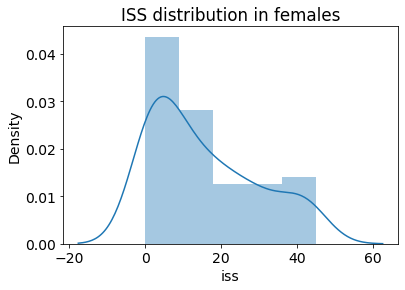

In [108]:
font = {'weight' : 'normal',
        'size'   : 14}
plt.rc('font', **font)

sns.distplot(clin[clin['sex']=='Female']['iss'])
plt.title('ISS distribution in females')

In [111]:
print(clin[clin['sex']=='Female']['iss'].min())
print(clin[clin['sex']=='Female']['iss'].max())

0
45


/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'ISS distribution in males')

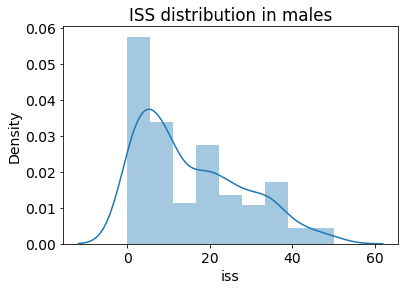

In [109]:
sns.distplot(clin[clin['sex']=='Male']['iss'])
plt.title("ISS distribution in males")

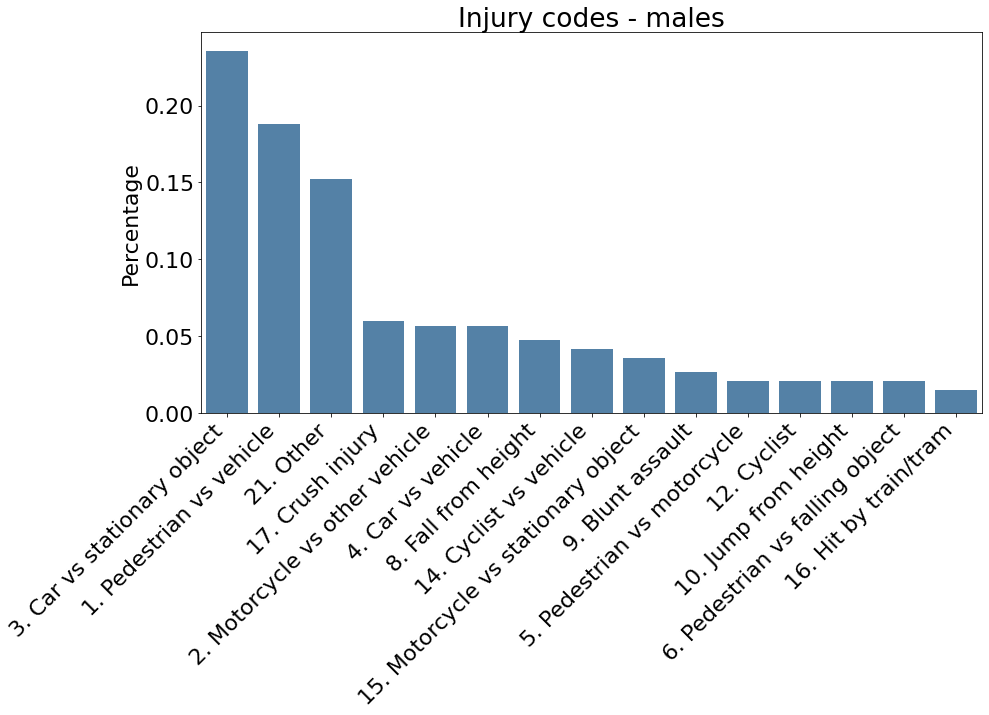

In [98]:
font = {'weight' : 'normal',
        'size'   : 22}
plt.rc('font', **font)

fig= plt.figure(figsize = (14, 7))
sns.barplot(x = clin[clin['sex']=='Male']['injury_code'].unique() , 
y = clin[clin['sex']=='Male']['injury_code'].value_counts(normalize=True),
color='steelblue')
plt.xticks(rotation = 45, ha='right')
plt.title("Injury codes - males")
plt.ylabel("Percentage");

In [103]:
clin[clin['sex']=='Male']['injury_code'].value_counts(normalize=True)

8. Fall from height                    0.235821
1. Pedestrian vs vehicle               0.188060
2. Motorcycle vs other vehicle         0.152239
14. Cyclist vs vehicle                 0.059701
4. Car vs vehicle                      0.056716
9. Blunt assault                       0.056716
17. Crush injury                       0.047761
3. Car vs stationary object            0.041791
15. Motorcycle vs stationary object    0.035821
10. Jump from height                   0.026866
21. Other                              0.020896
5. Pedestrian vs motorcycle            0.020896
6. Pedestrian vs falling object        0.020896
16. Hit by train/tram                  0.020896
12. Cyclist                            0.014925
Name: injury_code, dtype: float64

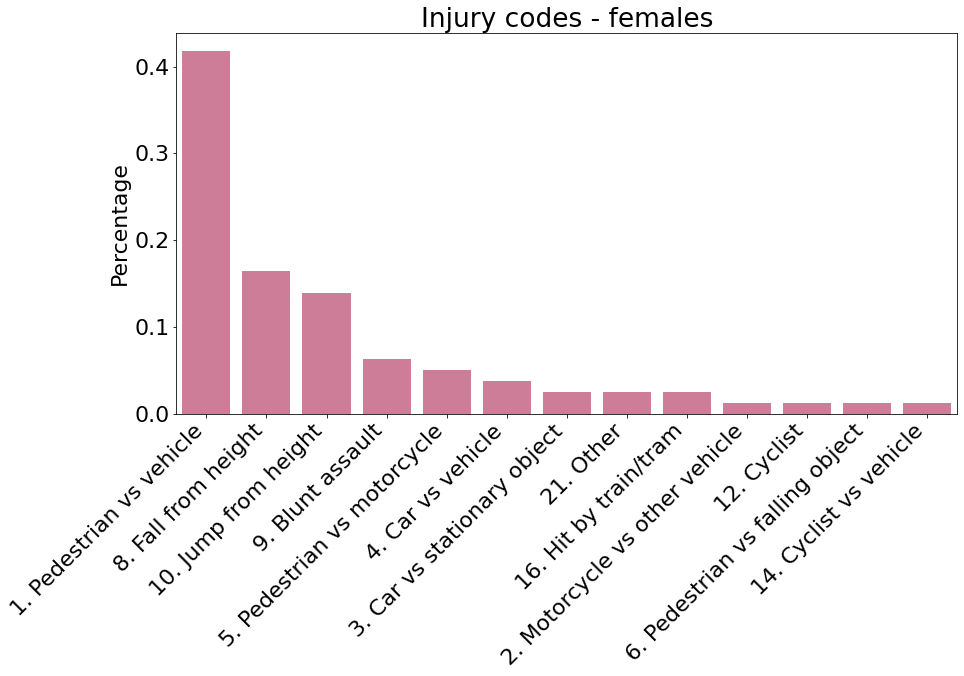

In [99]:
fig= plt.figure(figsize = (14, 7))
sns.barplot(x = clin[clin['sex']=='Female']['injury_code'].unique() , 
y = clin[clin['sex']=='Female']['injury_code'].value_counts(normalize=True),
color='palevioletred')
plt.xticks(rotation = 45, ha='right')
plt.title('Injury codes - females')
plt.ylabel("Percentage");

In [54]:
clin[clin['sex']=='Female']['age'].median()

36.0

In [66]:
clin[clin['sex']=='Male']['injury_code'].unique()

array(['3. Car vs stationary object', '1. Pedestrian vs vehicle',
       '21. Other', '17. Crush injury', '2. Motorcycle vs other vehicle',
       '4. Car vs vehicle', '8. Fall from height',
       '14. Cyclist vs vehicle', '15. Motorcycle vs stationary object',
       '9. Blunt assault', '5. Pedestrian vs motorcycle', '12. Cyclist',
       '10. Jump from height', '6. Pedestrian vs falling object',
       '16. Hit by train/tram'], dtype=object)